<a href="https://colab.research.google.com/github/AnQuinteroS/Tareas_SenalesySistemas/blob/main/Ejercicios_Serie_FTT_y_Taller_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Ejercicios Transformada de Fourier***


###1.   Presente y describa el modelo que utiliza la FFT para el cálculo de los armónicos.

 La FFT  es un algoritmo eficiente que permite calcular la transformada de Fourier discreta (DFT) y su inversa. El modelo que se utiliza para el cálculo de los armónicos mediante la FFT se basa en la idea de que una señal periódica puede ser descompuesta en una serie de armónicos sinusoidales con diferentes frecuencias y amplitudes.

En la FFT, se realiza una descomposición de la señal en componentes sinusoidales mediante la DFT, que permite obtener los armónicos de la señal en el dominio de la frecuencia. Cada armónico está representado por una componente espectral en la transformada de Fourier, que indica la amplitud y la fase del armónico correspondiente.

El modelo de la FFT para el cálculo de los armónicos implica los siguientes pasos:



*   Se toma una señal discreta en el dominio del tiempo, que se asume periódica.

$$x[n] = x(t)_{t=nT}$$

*   Se aplica la DFT a la señal para obtener su representación en el dominio de la frecuencia.

$$X[k] = \sum\limits_{n=0}^{N-1} x[n] e^{-\frac{2\pi i}{n} n k }$$

*   Se identifican los armónicos de la señal a partir de las componentes espectrales obtenidas en la transformada de Fourier. Cada armónico está representado por una componente espectral en la transformada de Fourier, que indica la amplitud y la fase del armónico correspondiente.
*   Se ordenan los armónicos por su frecuencia, y se eliminan aquellos que tienen amplitudes muy pequeñas, considerándolos como ruido o interferencias.

*   Se reconstruye la señal original a partir de los armónicos identificados, sumando cada armónico con su respectiva amplitud y fase.


###2.   Realice una comparación del tiempo de cómputo requerido para el cálculo de la transformada discreta de Fourier utilizado la estimación por sumatoria vs la FFT. Pruebe distintos valores de longitud de la señal de entrada (4,8,16,32,64,128,256,512,1024,2048,4096). Presente una gráfica comparativa de los tiempos de ejecución en segundos vs la longitud de la señal de entrada.

Para medir el tiempo de ejecución utilizaremos la librería *Time* e implementaremos un ciclo que vaya asignando los distintos valores de longitud propuestos a una señal aleatoria. Así:

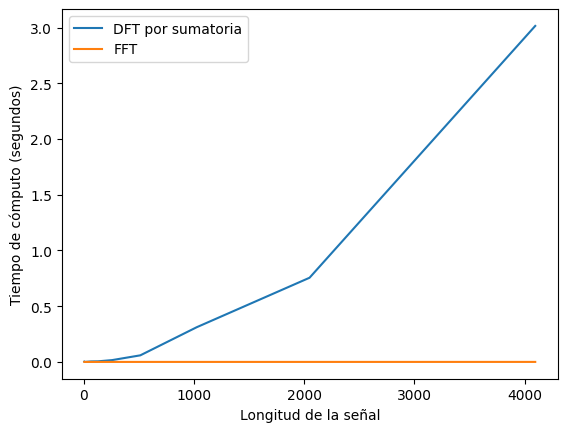

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

LnS = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
dft_times = []
fft_times = []

for length in LnS:
  x = np.random.randn(length) #Señal de entrada aleatoria de longitud "length"

  start_time = time.time() #Transformada discreta de Fourier por estimación por sumatoria
  dft = np.array([sum(x * np.exp(-2j*np.pi*k*np.arange(length)/length)) for k in range(length)])
  end_time = time.time()
  dft_times.append(end_time - start_time)

  start_time = time.time() #Transformada rápida de Fourier
  fft = np.fft.fft(x)
  end_time = time.time()
  fft_times.append(end_time - start_time)

plt.plot(LnS, dft_times, label="DFT por sumatoria") #Graficamos la comparativa
plt.plot(LnS, fft_times, label="FFT")
plt.xlabel("Longitud de la señal")
plt.ylabel("Tiempo de cómputo (segundos)")
plt.legend()
plt.show()

###3. Implemente un filtro pasa bajas, un pasa altas, un pasa bandas, y un rechaza bandas utilizando la FFT y la iFFT sobre 5 segundos de su canción favorita de YouTube.

In [ ]:
# Para graficar
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# filtrado espectral utilizando FFT con señal de audio

- Se utilizará la `fft` para filtrar una señal de audio.

- Se puede usar la API `youtube-dl` para descargar un video de youtube y extraer el audio en formato mp3.

In [ ]:
!python3 -m pip install --force-reinstall https://github.com/yt-dlp/yt-dlp/archive/master.tar.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 12.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.3/158.3 kB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 21.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.7/138.7 kB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 kB 6.0 MB/s eta 0:00:00
  Created w

- Se debe incluir el link del video a procesar:

In [ ]:
link="https://www.youtube.com/watch?v=G7KNmW9a75Y"
!yt-dlp --extract-audio -o "audio" --audio-format mp3 {link}
import subprocess


[youtube] Extracting URL: https://www.youtube.com/watch?v=G7KNmW9a75Y
[youtube] G7KNmW9a75Y: Downloading webpage
[youtube] G7KNmW9a75Y: Downloading ios player API JSON
[youtube] G7KNmW9a75Y: Downloading android player API JSON
[youtube] G7KNmW9a75Y: Downloading m3u8 information
[info] G7KNmW9a75Y: Downloading 1 format(s): 251
[download] Destination: audio
[download] 100% of    3.11MiB in 00:00:00 at 20.19MiB/s
[ExtractAudio] Destination: audio.mp3
Deleting original file audio (pass -k to keep)


- Se convierte el audio a .wav para procesar:

In [ ]:
!ffmpeg -y -i audio.mp3 output.wav

ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

Librería para manipulación de archivos de audio

In [ ]:
!pip install soundfile

In [ ]:
import soundfile as sf # para instalar pip install soundfile
#lee archivos wav
nombre_out = "output.wav"
x, fs = sf.read(nombre_out)
# read speech signal from file
print('Frecuencia de muestreo %.2f[Hz]\naudio %s' % (fs,nombre_out))

El audio viene codificado en dos canales:

In [ ]:
x.shape

In [ ]:
from IPython.display import Audio
ns = 30 #se reproducen los primeros ns segundos
Audio(x[:int(fs*ns),:].T,rate=fs)

- Se gráfica un intervalo de la señal en el tiempo:

In [ ]:
xpro = x.copy() #copiar archivos para procesar
ti = 10 #tiempo incio a procesar seg
tf = 15 #tiempo final a procesar seg
xs = xpro[int(ti*fs):int((tf*fs)),:]

tt = np.arange(ti,tf,1/fs) # vector de tiempo
plt.plot(tt,xs)
plt.legend(('canal 1','canal 2'))
plt.xlabel('$t[s]$')
plt.ylabel('$x(t)$')
plt.show()

- Se cálcula el espectro de Fourier del segmento de audio escogido sobre cada canal (sonido estereo).

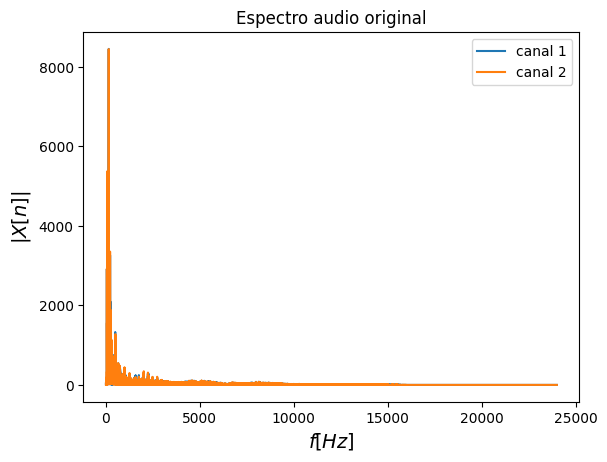

In [ ]:
Xw = np.fft.rfft(xs,axis=0) # axis=0 permite aplicar fft por cada columna de xpro
vf = np.fft.rfftfreq(np.size(xs,0),1/fs) #se crea el vector de frecuencias
plt.plot(vf,abs(Xw))#se grafica la magnitud
plt.legend(('canal 1','canal 2'))
plt.title(r'Espectro audio original')
plt.xlabel(r'$f[Hz]$',fontsize = 14)
plt.ylabel(r'$|X[n]|$',fontsize = 14)
plt.show()

# Tipos de filtrado

- Según el rango de frecuencias a filtrar (según el diagrama de magnitud), los filtros se pueden clasificar en:

  - Filtro pasa-bajas (low-pass)
  - Filtro pasa-altas (high-pass)
  - Filtro pasa-banda (band-pass)
  - Filtro rechaza banda (band-stop)

  ![filtros](https://github.com/amalvarezme/SenalesSistemas/blob/master/3_SerieyTransformadaFourier/filters2.jpg?raw=1)





##  En este caso, se plantea un filtro pasa banda.






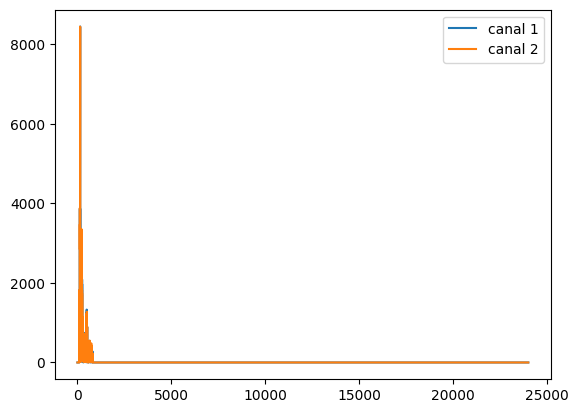

In [ ]:
#filtrar espectro
Xwf = Xw.copy()
f1 = 100 #frecuencia en Hz corte 1
f2 = 800 #frecuencia en Hz corte 2
ind = ~((vf > f1) & (vf < f2)) #frecuencias eliminar-> recueder que ~ actua como negación
Xwf[ind,:] = 0
plt.plot(vf,abs(Xwf))
plt.legend(('canal 1','canal 2'))
plt.show()

- Ahora, se reconstruye la señal mediante la fft inversa.

In [ ]:
xe2 = np.fft.irfft(Xwf,n=xs.shape[0],axis=0) #fft inversa sobre los dos canales de audio

In [ ]:
Audio(xe2[:int(fs*ns),:].T,rate=fs)#repoducir señal filtrada

# Guardar archivo filtrado en .wav

In [ ]:
name_out_fil = 'pasa_banda.wav'
sf.write(name_out_fil, xe2, fs)
print('Audio filtrado\n')

In [ ]:
2**12

4096

##En este caso, se plantea un filtro rechaza bandas.

In [ ]:
#filtrar espectro
Xwf2 = Xw.copy()
f1 = 100 #frecuencia en Hz corte 1
f2 = 800 #frecuencia en Hz corte 2
ind = (vf > f1) & (vf < f2) #frecuencias a eliminar: la banda entre f1 y f2
Xwf2[ind,:] = 0
plt.plot(vf,abs(Xwf2))
plt.legend(('canal 1','canal 2'))
plt.show()


- Ahora, se reconstruye la señal mediante la fft inversa.

In [ ]:
xe3 = np.fft.irfft(Xwf2,n=xs.shape[0],axis=0) #fft inversa sobre los dos canales de audio

In [ ]:
Audio(xe3[:int(fs*ns),:].T,rate=fs)#repoducir señal filtrada

##Guardar archivo filtrado en .wav

In [ ]:
name_out_fil = 'rechaza_banda.wav'
sf.write(name_out_fil, xe3, fs)
print('Audio filtrado 2\n')

In [ ]:
2**12

4096

##En este caso, se plantea un filtro pasa bajas.

In [ ]:
#filtrar espectro
Xwf3 = Xw.copy()
fc = 400 #frecuencia de corte
ind = vf > fc #frecuencias a eliminar: todas las mayores a fc
Xwf3[ind,:] = 0
plt.plot(vf,abs(Xwf3))
plt.legend(('canal 1','canal 2'))
plt.show()


- Ahora, se reconstruye la señal mediante la fft inversa.

In [ ]:
xe4 = np.fft.irfft(Xwf3,n=xs.shape[0],axis=0) #fft inversa sobre los dos canales de audio

In [ ]:
Audio(xe4[:int(fs*ns),:].T,rate=fs)#repoducir señal filtrada

##Guardar archivo filtrado en .wav

In [ ]:
name_out_fil = 'pasa_bajas.wav'
sf.write(name_out_fil, xe4, fs)
print('Audio filtrado 3\n')

In [ ]:
2**12

4096

##En este caso, se plantea un filtro pasa altas.

In [ ]:
#filtrar espectro
Xwf4 = Xw.copy()
fc = 800 #frecuencia de corte
ind = vf < fc #frecuencias a eliminar: todas las menores a fc
Xwf4[ind,:] = 0
plt.plot(vf,abs(Xwf4))
plt.legend(('canal 1','canal 2'))
plt.show()


- Ahora, se reconstruye la señal mediante la fft inversa.

In [ ]:
xe5 = np.fft.irfft(Xwf4,n=xs.shape[0],axis=0) #fft inversa sobre los dos canales de audio

In [ ]:
Audio(xe5[:int(fs*ns),:].T,rate=fs)#repoducir señal filtrada

##Guardar archivo filtrado en .wav

In [ ]:
name_out_fil = 'pasa_altas.wav'
sf.write(name_out_fil, xe5, fs)
print('Audio filtrado 4\n')

In [ ]:
2**12

4096

###4. Diseñe e implemente un detector de género musical, que permita diferenciar entre tres tipos de género. Para ello, construya una base de datos con al menos 30 registros por género musical, de 5 segundos cada uno, y luego implemente un código que permita recibir un nuevo registro músical de 5 segundos para detectar el género de la canción a partir de la distancia Euclídea entre la magnitud del espectro de Fourier del nuevo registro, y las magnitudes de los espectros de la base de datos construida (Ver [Cuaderno YouTube Download](https://github.com/amalvarezme/SenalesSistemas/blob/master/3_SerieyTransformadaFourier/youtube_download.ipynb)).

In [ ]:
!python3 -m pip install --force-reinstall https://github.com/yt-dlp/yt-dlp/archive/master.tar.gz

In [ ]:
import os
import yt_dlp as youtube_dl
def download_ytvid_as_mp3(video_url,name):
    #video_url = input("enter url of youtube video:")
    video_info = youtube_dl.YoutubeDL().extract_info(url = video_url,download=False)
    filename = f"{name}.mp3"
    options={
        'format':'bestaudio/best',
        'keepvideo':False,
        'outtmpl':filename,
        'noplaylist':True, # Agregar esta opción
    }

    with youtube_dl.YoutubeDL(options) as ydl:
        ydl.download([video_info['webpage_url']])

    print("Download complete... {}".format(filename))


#*Jazz*

In [ ]:
link_= ["https://www.youtube.com/watch?v=A3yCcXgbKrE",
        "https://www.youtube.com/watch?v=TLDflhhdPCg",
        "https://www.youtube.com/watch?v=oHRNrgDIJfo",
        "https://www.youtube.com/watch?v=ZEcqHA7dbwM",
        "https://www.youtube.com/watch?v=tO4dxvguQDk",
        "https://www.youtube.com/watch?v=dS5fMCYiQ9k",
        "https://www.youtube.com/watch?v=tYAHXaKlL6I",
        "https://www.youtube.com/watch?v=1bccOfePKVc",
        "https://www.youtube.com/watch?v=Web007rzSOI",
        "https://www.youtube.com/watch?v=YTeVkvaAYLE"
       ]
name_ = ['Jazz_1',
         'Jazz_2',
         'Jazz_3',
         'Jazz_4',
         'Jazz_5',
         'Jazz_6',
         'Jazz_7',
         'Jazz_8',
         'Jazz_9',
         'Jazz_10',
        ]
for name,link in zip(name_,link_):
    print(name)
    download_ytvid_as_mp3(link,name)

import subprocess

for name in name_:
    subprocess.call(['ffmpeg', '-i', name+'.mp3',
                   name+'.wav'])

In [ ]:
import soundfile as sf # para instalar pip install soundfile
#lee archivos wav
audios = globals().get('audios', {}) #diccionario con todos los registros
for name in name_:
    x, fs = sf.read(name+'.wav')
    audios[name] = (x, fs)

    print('Frecuencia de muestreo %.2f[Hz]\naudio %s' % (fs,name+'.wav'))

In [ ]:
from IPython.display import Audio
ns = 30 #se reproducen los primeros ns segundos
Audio(x[:int(fs*ns),:].T,rate=fs)

#*Bachata*

In [ ]:
link_= ["https://www.youtube.com/watch?v=DXiXPhvYuNU",
        "https://www.youtube.com/watch?v=b_HDhkw6g7I",
        "https://www.youtube.com/watch?v=39Pngb7MAas",
        "https://www.youtube.com/watch?v=OdaIbTUGmHM",
        "https://www.youtube.com/watch?v=6mM1zhFU1LU",
        "https://www.youtube.com/watch?v=W8r-eIhp4j0",
        "https://www.youtube.com/watch?v=jioYwyg3lmo",
        "https://www.youtube.com/watch?v=OST41MmjdTQ",
        "https://www.youtube.com/watch?v=tYUD9zpSTgw",
        "https://www.youtube.com/watch?v=PFMXOl3AQF0"
       ]
name_ = ['Bachata_1',
         'Bachata_2',
         'Bachata_3',
         'Bachata_4',
         'Bachata_5',
         'Bachata_6',
         'Bachata_7',
         'Bachata_8',
         'Bachata_9',
         'Bachata_10'
        ]
for name,link in zip(name_,link_):
    print(name)
    download_ytvid_as_mp3(link,name)

import subprocess

for name in name_:
    subprocess.call(['ffmpeg', '-i', name+'.mp3',
                   name+'.wav'])

import soundfile as sf # para instalar pip install soundfile
#lee archivos wav
audios = globals().get('audios', {}) #diccionario con todos los registros
for name in name_:
    x, fs = sf.read(name+'.wav')
    audios[name] = (x, fs)

    print('Frecuencia de muestreo %.2f[Hz]\naudio %s' % (fs,name+'.wav'))


In [ ]:
from IPython.display import Audio
ns = 30 #se reproducen los primeros ns segundos
Audio(x[:int(fs*ns),:].T,rate=fs)

# ***Ejercicios Taller 2***

**2.4 Aplicacion en circuitos eléctricos - potencia.** Consulte en
que consiste la distorsión total de armónicos (Total Harmonic Distortion-(THD)) y el factor de potencia en un circuito electrico. Cómo puede calcularse el THD desde la FFT?. Como puede calcularse la distorsión del factor de potencia
con base al THD?. Genere un ejemplo ilustrativo para el
calculo del THD y la distorsión del factor de potencia para un rectificador de onda completa con carga: i) netamente
resistiva y ii) carga RC en serie. Establezca las condiciones
necesarias para las simulaciones y pruebe con diferentes valores de R y C. Discuta los resultados obtenidos. Ver cuaderno Rectificador RC y THD.

**THD y Factor de Potencia**

El THD mide la distorsión harmónica en la forma de onda de salida de un circuito debido a la introducción de armónicos por elementos no lineales como rectificadores.

El factor de potencia indica que tan eficiente es la transferencia de potencia en un circuito AC. Un factor de potencia bajo indica pérdidas y distorsión.


**Cálculo del THD**

El THD se calcula como:

$THD = \frac{\sqrt{V_2^2 + V_3^2 + ... + V_n^2}}{V_1}$

Donde $V_n$ es la amplitud del armónico $n$ y $V_1$ es la amplitud fundamental.

Esto se puede calcular a partir de la FFT de la señal de salida.


**Cálculo de la Distorsión del Factor de Potencia**

La distorsión del factor de potencia a partir del THD es:

$PF_{THD} = \sqrt{\frac{1}{1+(THD)^2}}$

**Simulación**

A continuación se simula un rectificador de onda completa (puente de diodos ideales) alimentado con $v_s(t) = 170\sin(2\pi 60 t)$ y una resistencia de línea $R_s = 0.5\,\Omega$. Se analiza la corriente que entrega la red, que es donde se mide la distorsión que ve el sistema eléctrico.

* **Carga resistiva:** $R = 10\,\Omega$ y $R = 100\,\Omega$.
* **Carga RC:** el condensador se ubica en paralelo con $R$ (filtro capacitivo). Con $R$ y $C$ en serie del lado de DC, el condensador se carga hasta el pico de la fuente y la corriente se anula en estado estacionario, por lo que no hay régimen que analizar.

El THD se calcula con la FFT de 10 ciclos completos en estado estacionario, usando del 2.º al 50.º armónico.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Condiciones de simulación ---
Vm = 170          # Amplitud de la fuente [V] (120 V RMS)
f0 = 60           # Frecuencia de la red [Hz]
Rs = 0.5          # Resistencia de la línea/fuente [ohm]
fs_sim = 200_000  # Frecuencia de muestreo de la simulación [Hz]
ciclos = 30       # Ciclos simulados (los últimos 10 se analizan)

def rectificador(R, C=None):
    """Puente de diodos ideal con carga R o R en paralelo con C.
    Devuelve el tiempo, la corriente de línea is(t) y la tensión de carga."""
    dt = 1 / fs_sim
    t = np.arange(0, ciclos / f0, dt)
    vs = Vm * np.sin(2 * np.pi * f0 * t)
    i_s = np.zeros_like(t)
    vo = np.zeros_like(t)
    vc = 0.0
    for k, v in enumerate(vs):
        if C is None:
            io = abs(v) / (Rs + R)            # carga resistiva: conduce siempre
            vo[k] = io * R
            i_s[k] = np.sign(v) * io
        else:
            ic = (abs(v) - vc) / Rs            # los diodos conducen si |vs| > vC
            ic = max(ic, 0.0)
            vc += (ic - vc / R) * dt / C       # dvC/dt = (i - vC/R)/C
            vo[k] = vc
            i_s[k] = np.sign(v) * ic
    return t, i_s, vo

def thd_y_fp(t, i_s, v_fuente):
    """THD de la corriente y factor de potencia a partir de la FFT."""
    n = int(10 * fs_sim / f0)                  # 10 ciclos completos
    i_seg, v_seg = i_s[-n:], v_fuente[-n:]
    I = np.abs(np.fft.rfft(i_seg)) * 2 / n     # amplitud de cada armónico
    k1 = 10                                    # bin de 60 Hz (10 ciclos)
    armonicos = I[2 * k1:50 * k1 + 1:k1]       # 2.º al 50.º armónico
    thd = np.sqrt(np.sum(armonicos ** 2)) / I[k1]
    pf_dist = 1 / np.sqrt(1 + thd ** 2)
    pf_total = np.mean(v_seg * i_seg) / (np.std(v_seg) * np.sqrt(np.mean(i_seg**2)))
    return thd, pf_dist, pf_total, I, k1

casos = [("R = 10 Ω", 10, None),
         ("R = 100 Ω", 100, None),
         ("R = 100 Ω, C = 100 µF", 100, 100e-6),
         ("R = 100 Ω, C = 1000 µF", 100, 1000e-6),
         ("R = 10 Ω, C = 1000 µF", 10, 1000e-6)]

fig, ax = plt.subplots(len(casos), 2, figsize=(11, 2.4 * len(casos)))
print(f"{'Carga':<24}{'THD_i':>9}{'FP dist.':>10}{'FP total':>10}")
for fila, (nombre, R, C) in enumerate(casos):
    t, i_s, vo = rectificador(R, C)
    vs = Vm * np.sin(2 * np.pi * f0 * t)
    thd, pf_d, pf_t, I, k1 = thd_y_fp(t, i_s, vs)
    print(f"{nombre:<24}{100*thd:>8.1f}%{pf_d:>10.3f}{pf_t:>10.3f}")
    m = t >= t[-1] - 2 / f0
    ax[fila, 0].plot(1000 * t[m], i_s[m])
    ax[fila, 0].set_ylabel("is(t) [A]")
    ax[fila, 0].set_title(nombre, fontsize=10)
    ax[fila, 1].stem(np.arange(1, 16), I[k1:16 * k1:k1])
    ax[fila, 1].set_ylabel("|I_n| [A]")
    ax[fila, 1].set_title(f"THD = {100*thd:.1f} %", fontsize=10)
ax[-1, 0].set_xlabel("t [ms]")
ax[-1, 1].set_xlabel("Armónico n")
plt.tight_layout()
plt.show()

**Resultados y discusión**

| Carga | THD de la corriente | FP de distorsión | FP total |
|---|---|---|---|
| R = 10 Ω | 0.0 % | 1.000 | 1.000 |
| R = 100 Ω | 0.0 % | 1.000 | 1.000 |
| R = 100 Ω, C = 100 µF | 86.9 % | 0.755 | 0.657 |
| R = 100 Ω, C = 1000 µF | 150.7 % | 0.553 | 0.547 |
| R = 10 Ω, C = 1000 µF | 72.8 % | 0.809 | 0.751 |

* Con **carga resistiva** el puente de diodos toma una corriente $|v_s|/R$ en cada semiciclo, que vista desde la red es una senoidal pura: el THD es prácticamente 0 y el factor de potencia es 1, sin importar el valor de $R$.
* Al agregar el **condensador**, los diodos solo conducen durante los picos de la tensión, cuando $|v_s|$ supera la tensión del condensador. La corriente se convierte en pulsos angostos, ricos en armónicos impares (3.º, 5.º, 7.º...), y el factor de potencia cae.
* Un **condensador más grande** (o una carga más liviana, $R$ mayor) reduce el rizado de la salida pero hace los pulsos más angostos y altos, lo que aumenta el THD. Una carga más pesada ($R$ menor) descarga más el condensador, alarga el intervalo de conducción y reduce el THD.
* Por eso el filtrado capacitivo mejora la tensión de salida, pero **empeora** la calidad de la corriente que ve la red. En la práctica se corrige con filtros pasivos o con circuitos de corrección del factor de potencia (PFC).

**2.5 Aplicacion en comunicaciones - modulación AM.** Consulte en que consiste la modulación por amplitud por detección coherente y sus aplicaciones. Genere un ejemplo ilustrativo sobre Python en el que se grafique las señales en el tiempo y en frecuencia (utilizando la ‘rfft‘) para: señal mensaje tipo pulso rectangular y señal mensaje tipo coseno. El usuario podra definir el índice de modulacion de interés. Ver cuaderno Modulacion AM.

La modulación AM consiste en hacer variar la amplitud de una portadora senoidal de acuerdo a la señal de mensaje.

La señal modulada AM se calcula como:

$y(t) = (1 + \frac{m(t)}{A_c})c(t) = (1 + I_m\,\hat{m}(t))\,c(t)$

donde $\hat{m}(t)$ es el mensaje normalizado a amplitud pico 1. En el código se usa esta segunda forma, para poder fijar directamente el índice de modulación `Im`.

Donde:

* $c(t)$ es la portadora senoidal
* $m(t)$ es la señal de mensaje
* $A_c$ es la amplitud de la portadora
El índice de modulación indica la profundidad de la modulación:

$I_m = \frac{\text{Peak}{m(t)}}{A_c}$

A continuación se muestra un ejemplo con dos tipos de señales de mensaje:

# Mensaje rectángular:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Fc = 100 # Frecuencia portadora
Fs = 1000 # Frecuencia de muestreo
t = np.linspace(0, 1, Fs+1)
Ac = 1

# Señal de mensaje rectangular
Fm = 10
Im = 0.8
m = np.sign(np.sin(2*np.pi*Fm*t))
c = Ac*np.cos(2*np.pi*Fc*t)
y = (1 + Im*m)*c  # Im define la profundidad de modulación

plt.subplot(3,1,1)
plt.plot(t, m)
plt.ylabel('m(t)')

plt.subplot(3,1,2)
plt.plot(t, y)
plt.ylabel('y(t)')

plt.subplot(3,1,3)
Xy = np.fft.rfft(y)
f = np.fft.rfftfreq(len(y), 1/Fs)  # eje en Hz
plt.plot(f, np.abs(Xy))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|Y(f)|')

plt.tight_layout()
plt.show()

# Mensaje coseno:

In [ ]:
# Señal de mensaje coseno
Im = 0.5 # índice de modulación
Fm = 5
m = np.cos(2*np.pi*Fm*t)
y = (1 + Im*m)*c

plt.subplot(3,1,1)
plt.plot(t, m)
plt.ylabel('m(t)')

plt.subplot(3,1,2)
plt.plot(t, y)
plt.ylabel('y(t)')

plt.subplot(3,1,3)
Xy = np.fft.rfft(y)
f = np.fft.rfftfreq(len(y), 1/Fs)  # eje en Hz
plt.plot(f, np.abs(Xy))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|Y(f)|')

plt.tight_layout()
plt.show()

Se puede cambiar el índice de modulación Im y observar el efecto en la señal modulada y el espectro.